      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

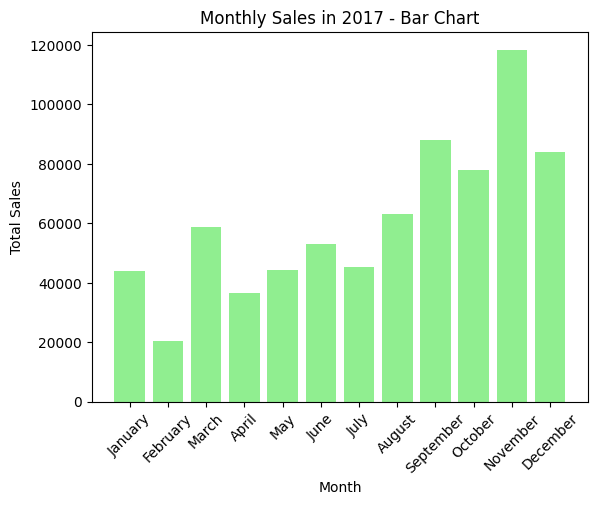

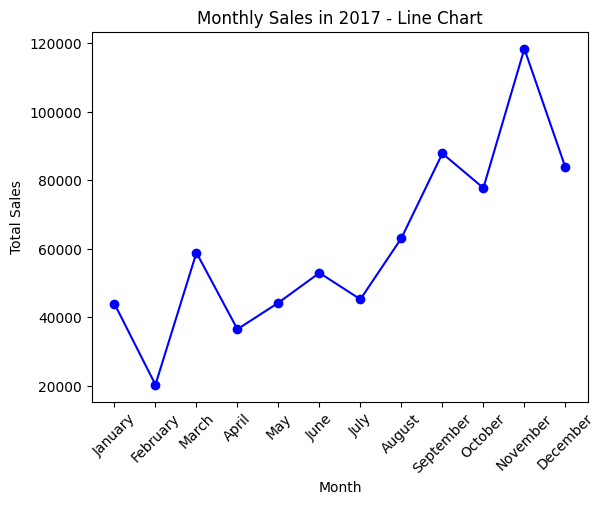

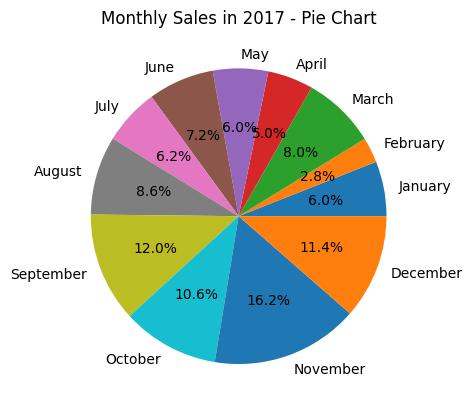

In [8]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

print(df)

# Display first 5 rows
print(df.head())

# Convert Order Date into date format
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Select data from 2017
df_2017 = df[df["Order Date"].dt.year == 2017]

# Calculate total sales for each month
monthly_sales = df_2017.groupby(
    df_2017["Order Date"].dt.month
)["Sales"].sum()

# months names
monthly_sales.index = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

print(monthly_sales)

#  BAR CHART
plt.bar(monthly_sales.index, monthly_sales.values, color="lightgreen")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales in 2017 - Bar Chart")

plt.xticks(rotation=45)

plt.show()

# LINE CHART
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    color="blue"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales in 2017 - Line Chart")

plt.xticks(rotation=45)

plt.show()

#  PIE CHART
plt.pie(
    monthly_sales.values,
    labels=monthly_sales.index,
    autopct="%1.1f%%"
)

plt.title("Monthly Sales in 2017 - Pie Chart")

plt.show()# Import libraries


The line chart shows the trend best because the connected points make it easy to see how sales increase or decrease from month to month. The pie chart hides the trend because it shows each month's proportion of total sales rather than the order and progression of the months. The bar chart is useful for comparing the sales of individual months.

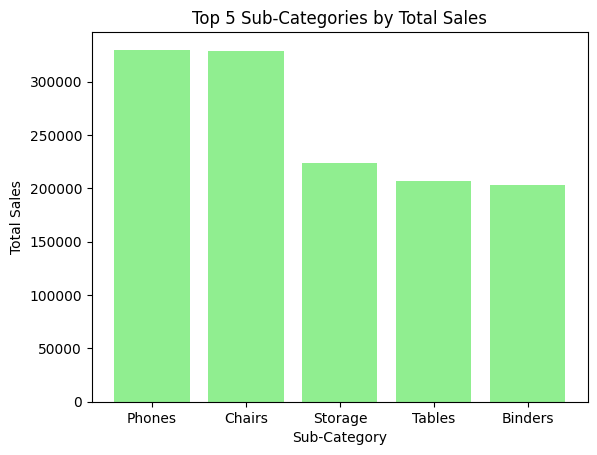

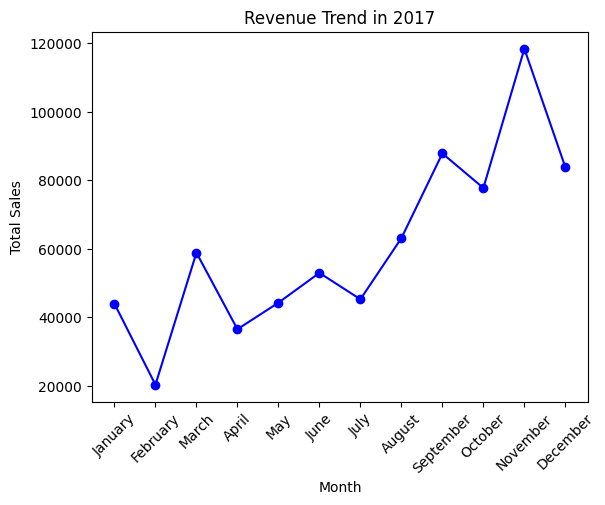

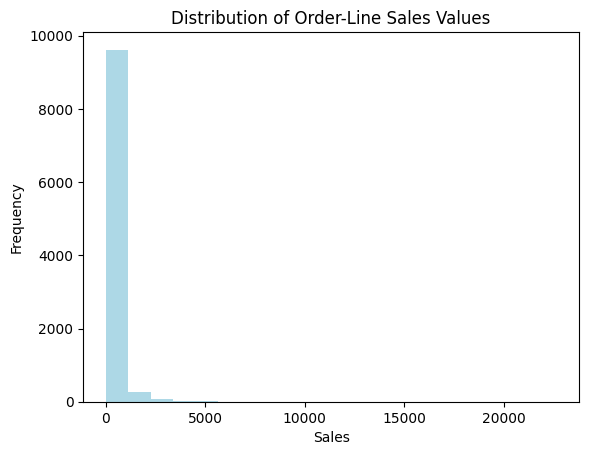

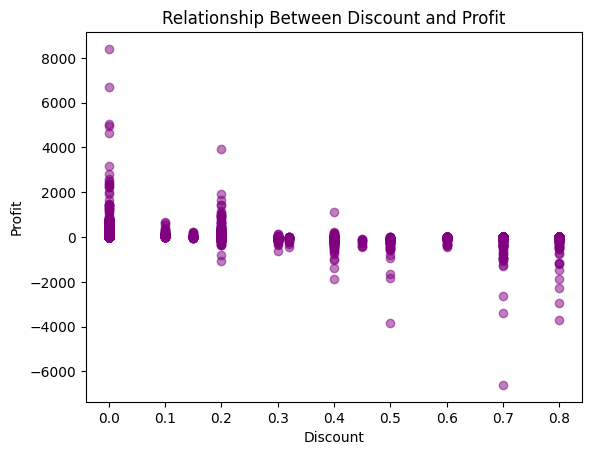

In [10]:
# 1. TOP 5 SUB-CATEGORIES BY TOTAL SALES
# Bar Chart
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum()

top5 = subcategory_sales.sort_values(ascending=False).head(5)

plt.bar(top5.index, top5.values, color="lightgreen")

plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.title("Top 5 Sub-Categories by Total Sales")

plt.show()

# 2. REVENUE TREND OVER TIME
# Line Chart
# Using 2017 monthly sales from Task 1
df_2017 = df[df["Order Date"].dt.year == 2017]

monthly_sales = df_2017.groupby(
    df_2017["Order Date"].dt.month
)["Sales"].sum()

monthly_sales.index = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    color="blue"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Revenue Trend in 2017")

plt.xticks(rotation=45)

plt.show()

# 3. DISTRIBUTION OF ORDER-LINE SALES VALUES
# Histogram
plt.hist(df["Sales"], bins=20, color="lightblue")

plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Order-Line Sales Values")

plt.show()

# 4. RELATIONSHIP BETWEEN DISCOUNT AND PROFIT
# Scatter Plot
plt.scatter(
    df["Discount"],
    df["Profit"],
    color="purple",
    alpha=0.5
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Relationship Between Discount and Profit")

plt.show()

1. Bar Chart:
A bar chart is best for comparing total sales across the top 5 sub-categories because the differences between categories are easy to see. A pie chart would make comparing similar values more difficult.

2. Line Chart:
A line chart is best for showing the revenue trend because it clearly shows increases and decreases over time. A pie chart would hide the chronological trend.

3. Histogram:
A histogram is best for showing the distribution of order-line sales because it shows the frequency and shape of the numeric data. A bar chart would not be suitable because sales values are numeric rather than categories.

4. Scatter Plot:
A scatter plot is best for showing the relationship between discount and profit because both are numeric variables. A line chart would be a weak choice because the observations are individual data points, not a time-based sequence.

/tmp/ipykernel_821/50156889.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


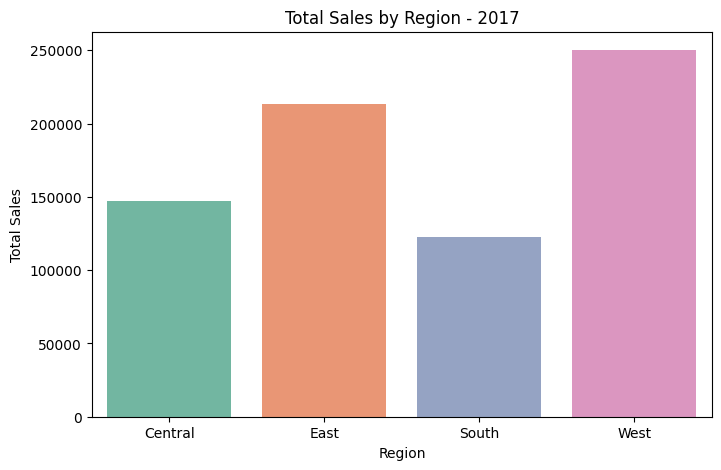

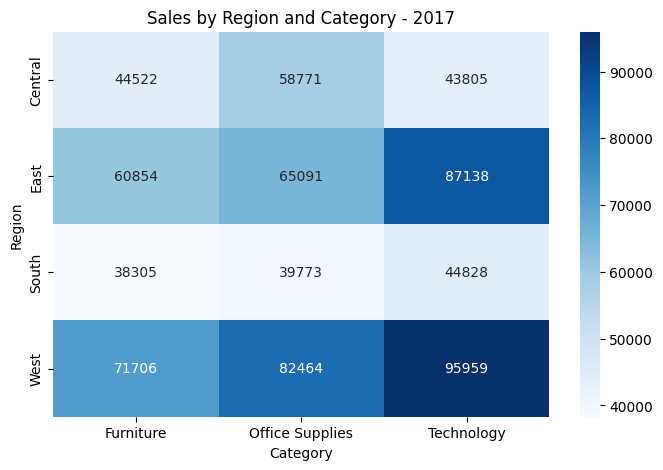

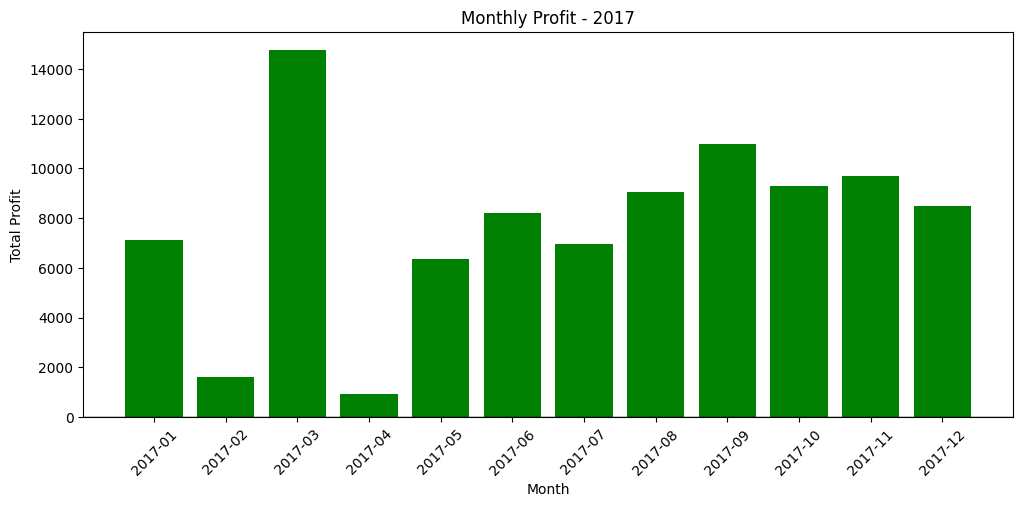

In [12]:
import seaborn as sns

# (a) Total Sales by Region
# Categorical Palette
region_sales = df_2017.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="Set2"
)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region - 2017")

plt.show()
# (b) Sales by Region and Category
# Sequential Heatmap
region_category_sales = pd.pivot_table(
    df_2017,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    region_category_sales,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.xlabel("Category")
plt.ylabel("Region")
plt.title("Sales by Region and Category - 2017")

plt.show()
# (c) Monthly Profit
# Diverging Colors
monthly_profit = df_2017.groupby(
    df_2017["Order Date"].dt.to_period("M")
)["Profit"].sum()

# Positive = green, Negative = red
colors = [
    "green" if value >= 0 else "red"
    for value in monthly_profit.values
]

plt.figure(figsize=(12, 5))

plt.bar(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    color=colors
)

# Zero reference line
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.title("Monthly Profit - 2017")

plt.xticks(rotation=45)

plt.show()

WCAG Contrast Ratio Results
Red vs White: 4.00:1 - FAIL
Green vs White: 5.14:1 - PASS
Blue vs White: 8.59:1 - PASS
White vs White: 1.00:1 - FAIL
Black vs White: 21.00:1 - PASS


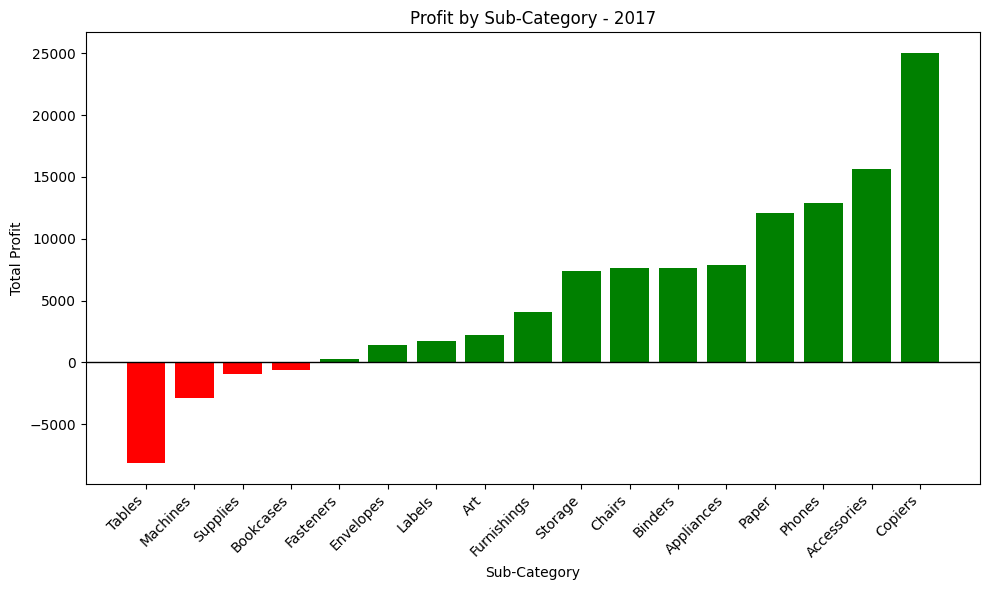

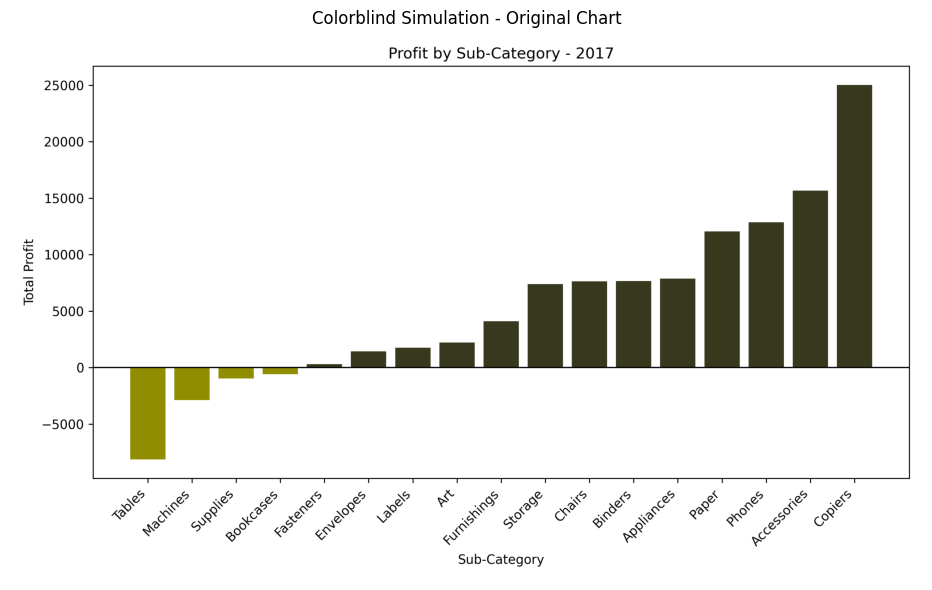

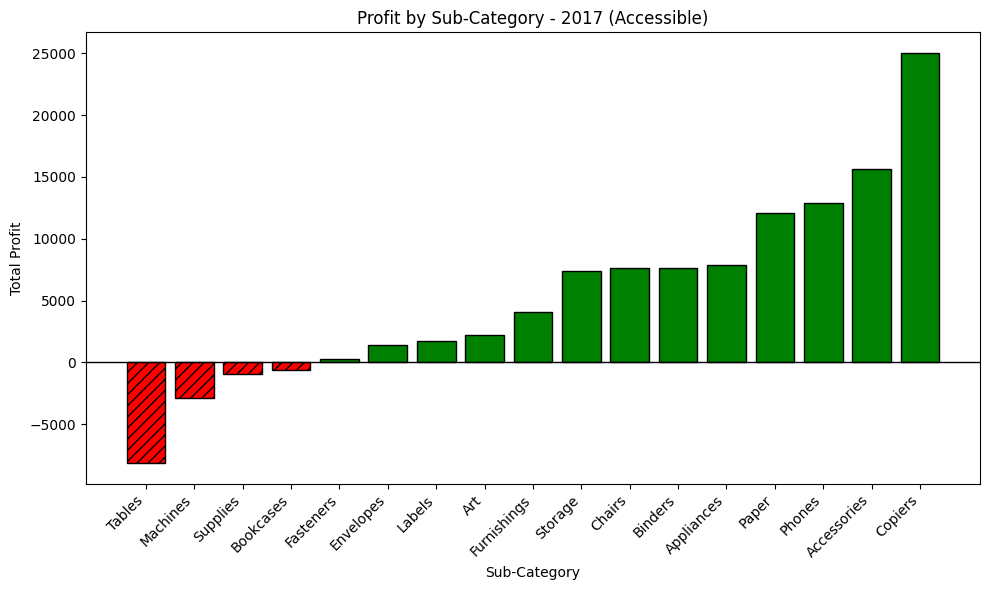

In [18]:
# WCAG Contrast Ratio Function
def relative_luminance(rgb):
    rgb = np.array(rgb) / 255

    rgb = np.where(
        rgb <= 0.03928,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    return (
        0.2126 * rgb[0]
        + 0.7152 * rgb[1]
        + 0.0722 * rgb[2]
    )


def contrast_ratio(color1, color2):
    l1 = relative_luminance(color1)
    l2 = relative_luminance(color2)

    lighter = max(l1, l2)
    darker = min(l1, l2)

    return (lighter + 0.05) / (darker + 0.05)

# Colors Used in Task 3

task3_colors = {
    "Red": (255, 0, 0),
    "Green": (0, 128, 0),
    "Blue": (0, 0, 255),
    "White": (255, 255, 255),
    "Black": (0, 0, 0)
}

print("WCAG Contrast Ratio Results")

for name, color in task3_colors.items():

    ratio = contrast_ratio(color, (255, 255, 255))

    if ratio >= 4.5:
        status = "PASS"
    else:
        status = "FAIL"

    print(f"{name} vs White: {ratio:.2f}:1 - {status}")
# Profit by Sub-Category - 2017
df["Year"] = df["Order Date"].dt.year

# Select 2017
year = 2017

year_df = df[df["Year"] == year]

profit_subcategory = (
    year_df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
)
# Original Chart - Red and Green
plt.figure(figsize=(10, 6))

colors = [
    "red" if value < 0 else "green"
    for value in profit_subcategory.values
]

plt.bar(
    profit_subcategory.index,
    profit_subcategory.values,
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title(f"Profit by Sub-Category - {year}")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("profit_original.png", dpi=300)
plt.show()
# Colorblind Simulation
# Protanopia Approximation

def simulate_protanopia(image):

    matrix = np.array([
        [0.567, 0.433, 0.000],
        [0.558, 0.442, 0.000],
        [0.000, 0.242, 0.758]
    ])

    image = image.astype(float) / 255

    simulated = image @ matrix.T

    return np.clip(
        simulated * 255,
        0,
        255
    ).astype(np.uint8)


original = plt.imread("profit_original.png")

if original.shape[2] == 4:
    original_rgb = original[:, :, :3]
else:
    original_rgb = original


simulated = simulate_protanopia(
    (original_rgb * 255).astype(np.uint8)
)

# Colorblind Simulation Image
plt.figure(figsize=(10, 6))

plt.imshow(simulated)
plt.axis("off")

plt.title("Colorblind Simulation - Original Chart")

plt.tight_layout()

plt.savefig(
    "profit_colorblind_simulation.png",
    dpi=300
)

plt.show()
# Fixed Chart - Color + Hatching
plt.figure(figsize=(10, 6))

for i, value in enumerate(profit_subcategory.values):

    if value < 0:
        color = "red"
        hatch = "///"
    else:
        color = "green"
        hatch = ""

    plt.bar(
        i,
        value,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )


plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    f"Profit by Sub-Category - {year} (Accessible)"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")

plt.xticks(
    range(len(profit_subcategory)),
    profit_subcategory.index,
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "profit_fixed.png",
    dpi=300
)

plt.show()

Profit by sub-category in 2017, with green bars representing gains and red hatched bars representing losses.

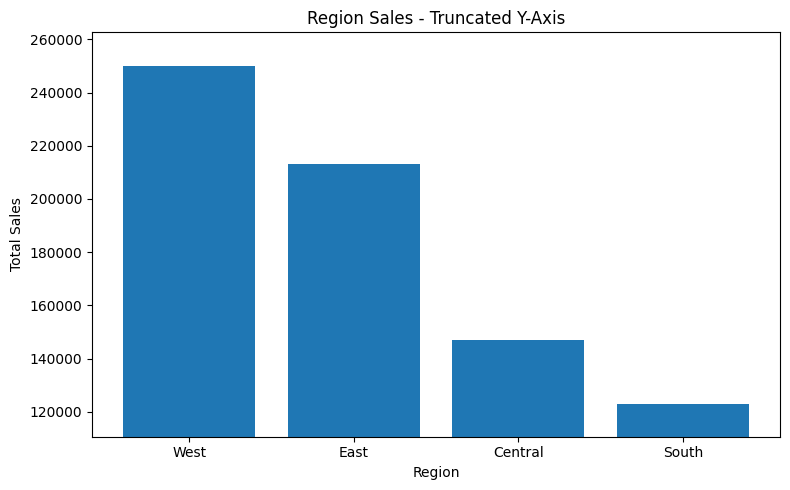

Caption: Truncated y-axis — the vertical axis starts above zero, exaggerating the visual differences between regions.


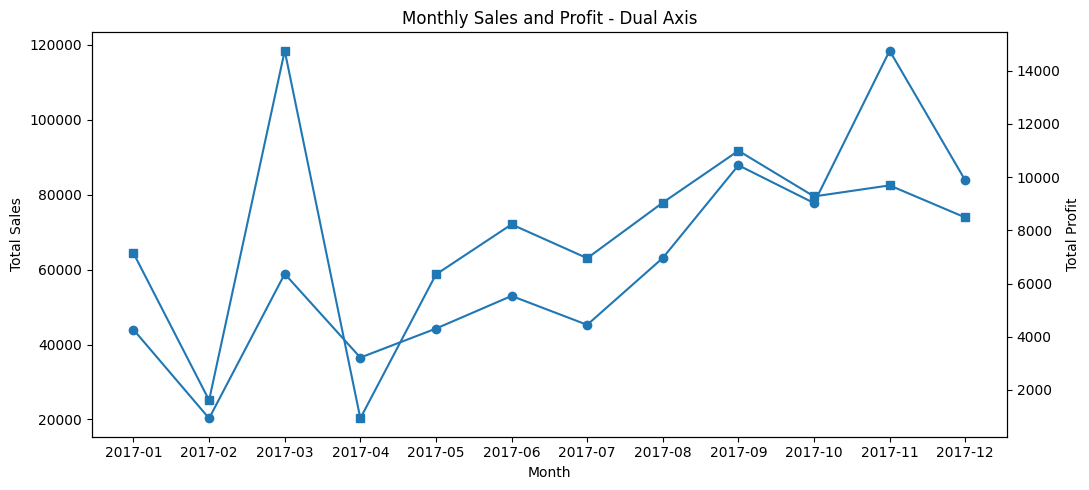

Caption: Dual-axis distortion — unrelated measures use separate y-axes, making visually aligned movements appear more correlated than they are.


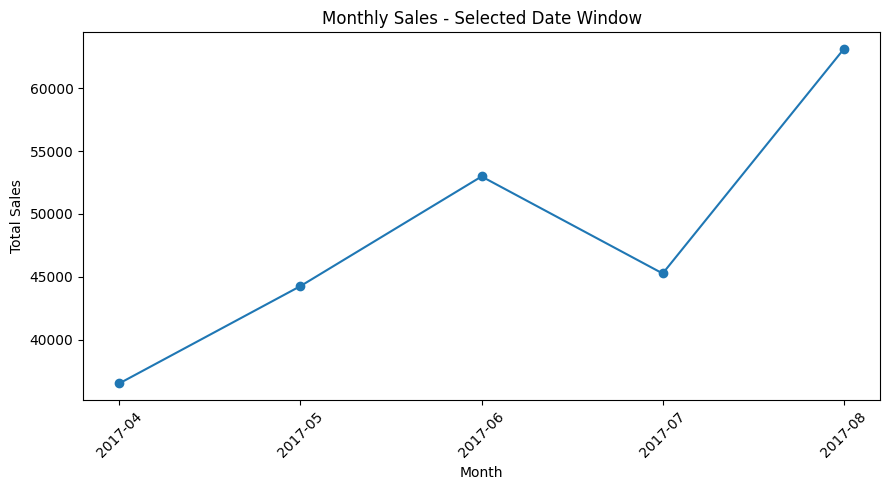

Caption: Cherry-picked date window — only a selected portion of the year is shown, hiding the surrounding trend and context.


In [20]:
# Region Sales
region_sales = (
    df_2017.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

# Monthly Sales and Monthly Profit

monthly_sales = (
    df_2017.groupby(
        df_2017["Order Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_profit = (
    df_2017.groupby(
        df_2017["Order Date"].dt.to_period("M")
    )["Profit"]
    .sum()
)

# 1. TRUNCATED Y-AXIS

plt.figure(figsize=(8, 5))

plt.bar(
    region_sales.index,
    region_sales.values
)

# Deliberately truncate the y-axis
plt.ylim(
    region_sales.min() * 0.90,
    region_sales.max() * 1.05
)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Region Sales - Truncated Y-Axis")

plt.tight_layout()
plt.show()

print(
    "Caption: Truncated y-axis — the vertical axis starts above zero, "
    "exaggerating the visual differences between regions."
)

# 2. DUAL-AXIS CHART
#    Monthly Sales + Monthly Profit

fig, ax1 = plt.subplots(figsize=(11, 5))

# Sales
ax1.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    label="Sales"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Sales")

# Profit on second axis
ax2 = ax1.twinx()

ax2.plot(
    monthly_profit.index.astype(str),
    monthly_profit.values,
    marker="s",
    label="Profit"
)

ax2.set_ylabel("Total Profit")

plt.title(
    "Monthly Sales and Profit - Dual Axis"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    "Caption: Dual-axis distortion — unrelated measures use separate "
    "y-axes, making visually aligned movements appear more correlated than they are."
)

# 3. CHERRY-PICKED DATE WINDOW
cherry_picked_sales = monthly_sales.iloc[3:8]

plt.figure(figsize=(9, 5))

plt.plot(
    cherry_picked_sales.index.astype(str),
    cherry_picked_sales.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.title(
    "Monthly Sales - Selected Date Window"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(
    "Caption: Cherry-picked date window — only a selected portion "
    "of the year is shown, hiding the surrounding trend and context."
)

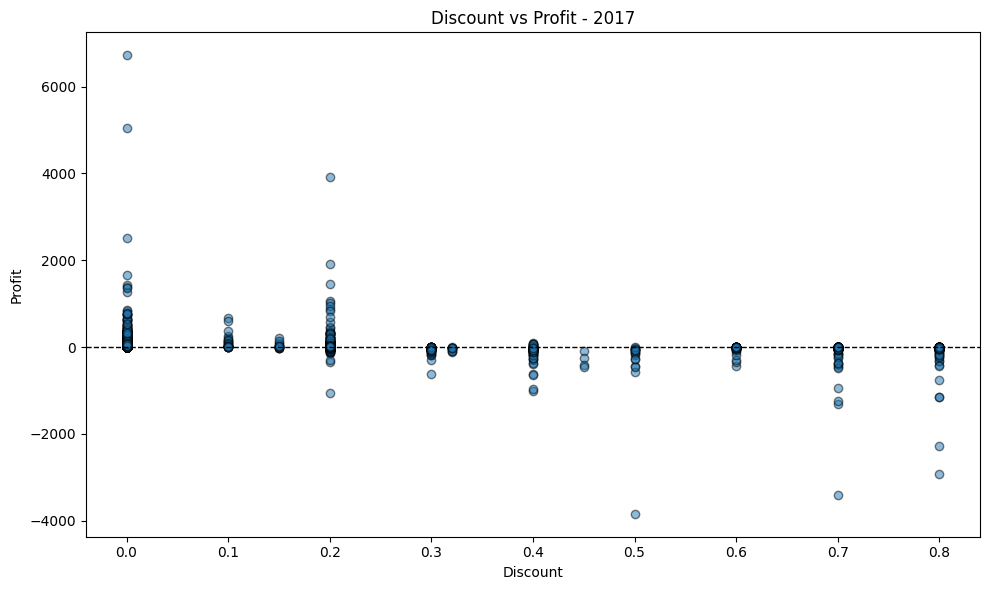

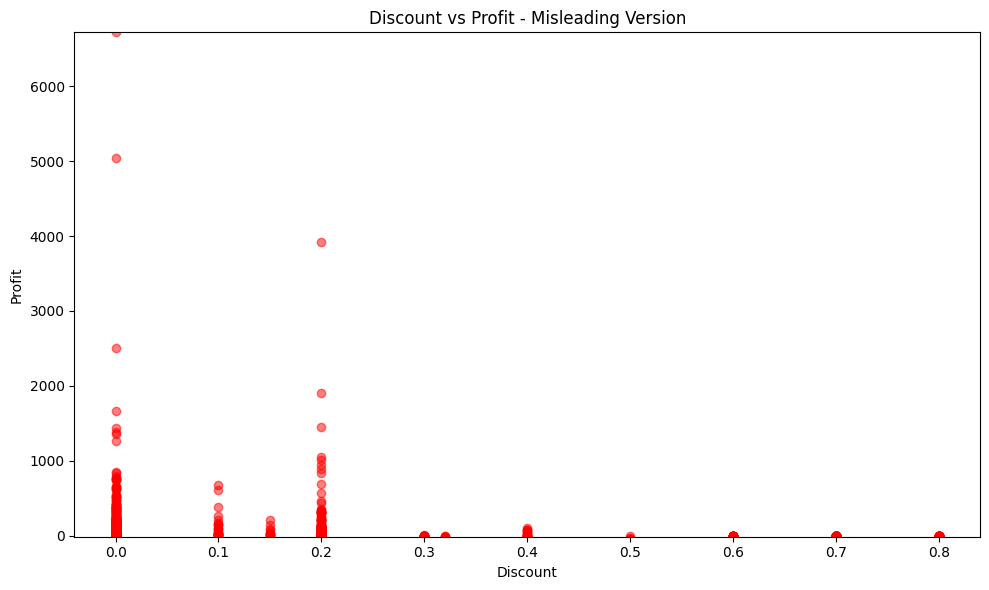

In [21]:
# ANALYTICAL QUESTION
# 1. HONEST CHART
# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2017["Discount"],
    df_2017["Profit"],
    alpha=0.5,
    edgecolor="black"
)

# Zero-profit reference line
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit - 2017")

plt.tight_layout()

plt.savefig(
    "honest_discount_profit.png",
    dpi=300
)

plt.show()

# 2. DELIBERATELY MISLEADING VERSION
# Truncated Y-axis
plt.figure(figsize=(10, 6))

plt.scatter(
    df_2017["Discount"],
    df_2017["Profit"],
    color="red",
    alpha=0.5
)

# Deliberately remove the lower portion of the y-axis
# to exaggerate the apparent relationship.
profit_min = df_2017["Profit"].quantile(0.10)
profit_max = df_2017["Profit"].max()

plt.ylim(
    profit_min,
    profit_max
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit - Misleading Version")

plt.tight_layout()

plt.savefig(
    "misleading_discount_profit.png",
    dpi=300
)

plt.show()